In [3]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import scipy.signal
import urllib.request

In [4]:
url = "https://www.soundhelix.com/examples/mp3/SoundHelix-Song-2.mp3"
urllib.request.urlretrieve(url, "sample_audio.mp3")

('sample_audio.mp3', <http.client.HTTPMessage at 0x20bd07ef6a0>)

In [5]:
sr_target = 22050
n_fft = 2048
hop_length = 512
n_mels = 128
fmin = 0

In [6]:
y, sr = librosa.load("sample_audio.mp3", sr=sr_target, mono=True)
fmax = sr / 2

In [7]:
def stft_from_scratch(signal, n_fft=2048, hop_length=512):

    window = scipy.signal.get_window("hann", n_fft)

    pad = n_fft // 2
    signal = np.pad(signal, pad, mode="reflect")

    n_frames = 1 + (len(signal) - n_fft) // hop_length
    stft = np.empty((n_fft//2 + 1, n_frames), dtype=np.complex64)

    for i in range(n_frames):
        start = i * hop_length
        frame = signal[start:start+n_fft]

        frame = frame * window

        spectrum = np.fft.rfft(frame)

        stft[:, i] = spectrum

    return stft


S_complex = stft_from_scratch(y, n_fft, hop_length)

S_power = np.abs(S_complex) ** 2

In [8]:
def hz_to_mel(hz):
    return 2595 * np.log10(1 + hz / 700)


def mel_to_hz(mel):
    return 700 * (10**(mel / 2595) - 1)

In [9]:
def mel_filterbank(sr, n_fft, n_mels, fmin, fmax):

    fft_bins = n_fft//2 + 1

    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)

    mel_points = np.linspace(mel_min, mel_max, n_mels + 2)

    hz_points = mel_to_hz(mel_points)

    bins = np.floor((n_fft + 1) * hz_points / sr).astype(int)

    bins = np.clip(bins, 0, fft_bins - 1)

    fb = np.zeros((n_mels, fft_bins))

    for m in range(1, n_mels + 1):

        left = bins[m - 1]
        center = bins[m]
        right = bins[m + 1]

        for k in range(left, center):
            fb[m-1, k] = (k - left) / max(1, center - left)

        for k in range(center, right):
            fb[m-1, k] = (right - k) / max(1, right - center)

    return fb

In [10]:
mel_fb = mel_filterbank(sr, n_fft, n_mels, fmin, fmax)

mel_spec = np.dot(mel_fb, S_power)

mel_db = 10 * np.log10(np.maximum(mel_spec, 1e-10))

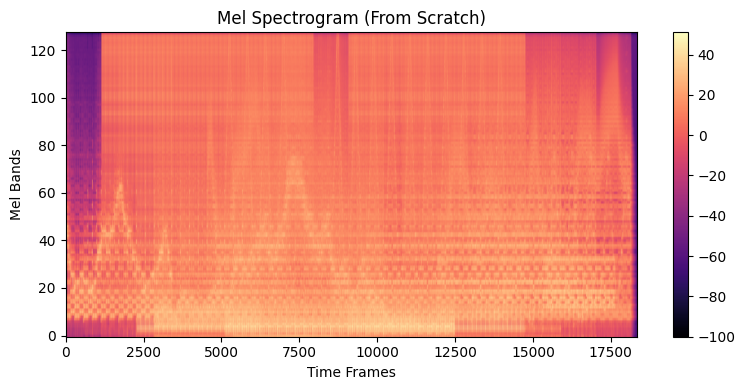

In [11]:
plt.figure(figsize=(8,4))

plt.imshow(mel_db,
           aspect='auto',
           origin='lower',
           cmap='magma')

plt.title("Mel Spectrogram (From Scratch)")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bands")

plt.colorbar()

plt.tight_layout()

plt.show()